# Segmentasi Mobil Bekas Berdasarkan Karakteristik dan Harga
### Implementasi Clustering (K-Means) dengan Metodologi CRISP-DM

**Dataset:** `car_price_dataset.csv` (2000 baris, 11 kolom)

**Disusun oleh:** *(isi nama & NIM Anda di sini)*

---

Notebook ini menyusun sebuah project *unsupervised learning* sederhana untuk menemukan
kelompok (cluster) tersembunyi pada data mobil bekas, mengikuti enam tahap **CRISP-DM**:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


## 1. Business Understanding

### 1.1 Latar Belakang
Sebuah platform jual-beli mobil bekas memiliki ribuan listing dengan atribut yang beragam
(merek, tahun produksi, kapasitas mesin, jenis bahan bakar, transmisi, jarak tempuh, jumlah
pintu, jumlah pemilik sebelumnya, tenaga mesin/horsepower, dan harga). Tim bisnis ingin
memahami **segmen alami** yang terbentuk dari mobil-mobil tersebut tanpa menggunakan label
kategori yang sudah ada (seperti Brand), agar dapat:

- Menyusun strategi *pricing* dan promosi yang lebih tepat sasaran per segmen.
- Membantu tim marketing membuat *persona* pembeli/penjual untuk tiap segmen mobil.
- Mendeteksi kelompok mobil "bernilai tinggi" (harga tinggi, mileage rendah, HP tinggi) vs
  kelompok "ekonomis" (harga rendah, mileage tinggi, HP rendah), dsb.

### 1.2 Tujuan Data Mining
Menerapkan algoritma **clustering (K-Means)** pada data numerik kendaraan untuk menemukan
kelompok mobil yang memiliki karakteristik serupa (usia, mesin, jarak tempuh, harga, dsb.),
lalu memberikan **profil/interpretasi bisnis** untuk setiap cluster yang terbentuk.

### 1.3 Kriteria Keberhasilan
- Diperoleh jumlah cluster optimal yang didukung oleh metrik evaluasi (*Elbow Method* &
  *Silhouette Score*).
- Setiap cluster memiliki karakteristik yang **berbeda secara jelas** dan **dapat
  diinterpretasikan** secara bisnis.
- Hasil clustering dapat digunakan ulang (deployment) untuk memprediksi cluster dari
  mobil/listing baru.


## 2. Data Understanding

Pada tahap ini kita akan memuat dataset, melihat struktur data, tipe data, statistik
deskriptif, missing value, serta melakukan eksplorasi visual awal (EDA) untuk memahami
karakteristik data sebelum masuk ke tahap persiapan data.


In [1]:
# Import library dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)


In [2]:
# 2.1 Memuat dataset
df = pd.read_csv('car_price_dataset.csv')
print('Ukuran dataset:', df.shape)
df.head()


Ukuran dataset: (2000, 11)


,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [3]:
# 2.2 Informasi struktur data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   str    
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   str    
 5   Transmission  2000 non-null   str    
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), str(3)
memory usage: 172.0 KB


In [4]:
# 2.3 Statistik deskriptif untuk kolom numerik
df.describe()


,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,2013.963000,2.967550,100736.956500,2.988000,2.532500,235.70950,46169.507675
std,577.494589,5.508248,1.146926,56002.915221,0.818041,1.125423,95.59811,9211.685713
min,1.000000,2005.000000,1.000000,5036.000000,2.000000,1.000000,70.00000,18911.550000
25%,500.750000,2009.000000,2.000000,52365.500000,2.000000,2.000000,154.00000,39764.000000
50%,1000.500000,2014.000000,2.900000,100590.500000,3.000000,3.000000,236.00000,46112.350000
75%,1500.250000,2019.000000,4.000000,148024.500000,4.000000,4.000000,319.00000,52471.387500
max,2000.000000,2023.000000,5.000000,199904.000000,4.000000,4.000000,399.00000,72267.800000


In [5]:
# 2.4 Statistik deskriptif untuk kolom kategorikal
df.describe(include='object')


/tmp/ipykernel_143/735767829.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Brand,Fuel_Type,Transmission
count,2000,2000,2000
unique,6,4,2
top,Toyota,Diesel,Automatic
freq,352,537,1018


In [6]:
# 2.5 Pengecekan missing value dan data duplikat
print('Jumlah missing value per kolom:')
print(df.isnull().sum())
print('\nJumlah baris duplikat:', df.duplicated().sum())


Jumlah missing value per kolom:
Car_ID          0
Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64

Jumlah baris duplikat: 0


**Catatan:** Dataset tidak memiliki missing value maupun baris duplikat, sehingga
tahap pembersihan data dapat difokuskan pada seleksi fitur, encoding, dan penanganan
outlier/skewness (jika ada).

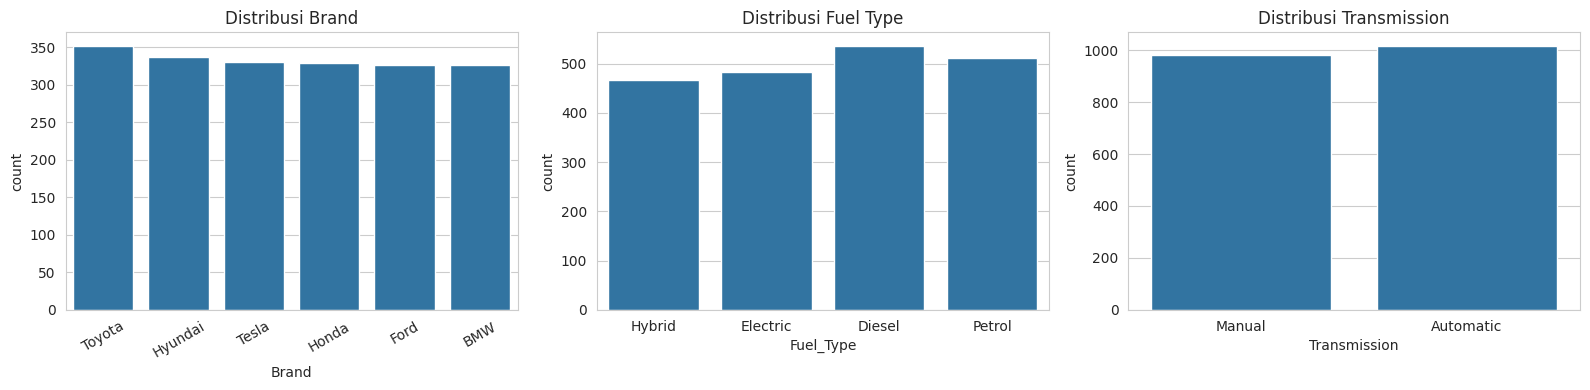

In [7]:
# 2.6 Distribusi variabel kategorikal
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='Brand', ax=axes[0], order=df['Brand'].value_counts().index)
axes[0].set_title('Distribusi Brand')
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='Fuel_Type', ax=axes[1])
axes[1].set_title('Distribusi Fuel Type')

sns.countplot(data=df, x='Transmission', ax=axes[2])
axes[2].set_title('Distribusi Transmission')

plt.tight_layout()
plt.show()


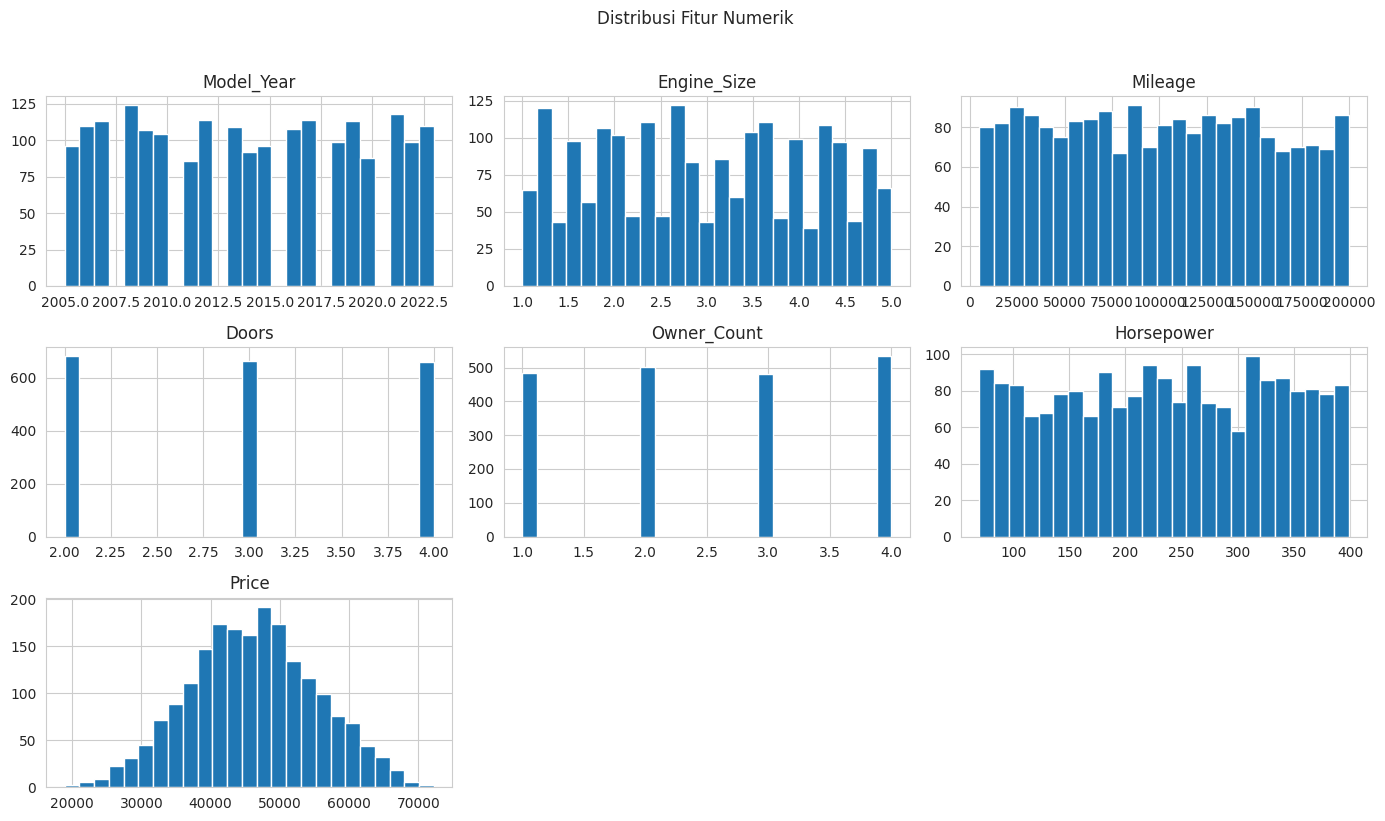

In [8]:
# 2.7 Distribusi variabel numerik
num_cols = ['Model_Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price']

df[num_cols].hist(bins=25, figsize=(14, 8))
plt.suptitle('Distribusi Fitur Numerik', y=1.02)
plt.tight_layout()
plt.show()


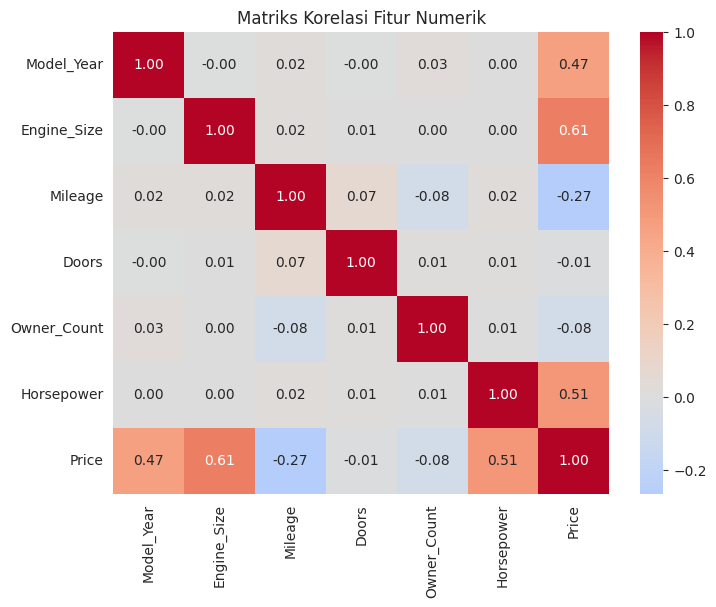

In [9]:
# 2.8 Korelasi antar fitur numerik
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()


**Insight awal:**
- `Owner_Count`, `Doors` bersifat diskrit dengan rentang sempit — kontribusinya terhadap
  varians cluster kemungkinan kecil.
- `Model_Year`, `Mileage`, `Engine_Size`, `Horsepower`, dan `Price` adalah kandidat utama
  fitur numerik yang menggambarkan karakteristik "kualitas/nilai" kendaraan.
- Korelasi antar fitur numerik tergolong lemah, artinya tidak ada multikolinearitas parah
  yang perlu dihilangkan sebelum clustering.


## 3. Data Preparation

Tahap ini mempersiapkan data agar siap digunakan oleh algoritma K-Means, yang mensyaratkan
seluruh fitur bersifat numerik dan berada pada skala yang sebanding.

Langkah-langkah:
1. Seleksi fitur relevan untuk clustering.
2. Encoding fitur kategorikal (`Fuel_Type`, `Transmission`) — `Brand` **tidak** diikutkan
   sebagai fitur input karena justru ingin dilihat bagaimana sebaran Brand di tiap cluster
   yang terbentuk (dipakai untuk interpretasi, bukan sebagai variabel pembentuk cluster).
3. Feature scaling (standardisasi) karena K-Means berbasis jarak Euclidean, sehingga fitur
   dengan skala besar (mis. `Mileage`, `Price`) tidak boleh mendominasi fitur berskala kecil
   (mis. `Engine_Size`).


In [10]:
# 3.1 Menambahkan fitur turunan: usia kendaraan (lebih mudah diinterpretasi daripada tahun)
current_year = 2026
df['Car_Age'] = current_year - df['Model_Year']

# 3.2 Seleksi fitur numerik untuk clustering
numeric_features = ['Car_Age', 'Engine_Size', 'Mileage', 'Horsepower', 'Price']

# 3.3 One-hot encoding untuk fitur kategorikal yang relevan
categorical_features = ['Fuel_Type', 'Transmission']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

# Gabungkan fitur numerik + kategorikal terencoding menjadi feature set clustering
X = pd.concat([df[numeric_features], df_encoded], axis=1)
X.head()


,Car_Age,Engine_Size,Mileage,Horsepower,Price,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual
0,3,1.2,180635,82,34309.25,False,True,False,True
1,8,3.2,35628,259,55153.60,True,False,False,True
2,18,2.2,74672,333,41894.40,False,False,False,True
3,9,2.2,51246,381,54046.70,False,False,True,False
4,14,2.4,147233,290,38010.35,True,False,False,True


In [11]:
# 3.4 Standardisasi fitur (mean=0, std=1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().round(2)


,Car_Age,Engine_Size,Mileage,Horsepower,Price,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.64,-1.72,-1.71,-1.73,-2.96,-0.57,-0.55,-0.59,-0.98
25%,-0.91,-0.84,-0.86,-0.85,-0.70,-0.57,-0.55,-0.59,-0.98
50%,-0.01,-0.06,-0.00,0.00,-0.01,-0.57,-0.55,-0.59,-0.98
75%,0.90,0.90,0.84,0.87,0.68,-0.57,-0.55,1.71,1.02
max,1.63,1.77,1.77,1.71,2.83,1.77,1.81,1.71,1.02


Setelah standardisasi, seluruh fitur numerik kini memiliki rata-rata mendekati 0 dan
standar deviasi 1, sehingga tiap fitur berkontribusi secara proporsional terhadap
perhitungan jarak pada K-Means.

## 4. Modeling

Algoritma yang digunakan adalah **K-Means Clustering**. Sebelum menentukan model final,
kita perlu menentukan jumlah cluster (*k*) yang optimal menggunakan:

- **Elbow Method** — melihat titik "siku" pada grafik *Within-Cluster Sum of Squares (WCSS)*.
- **Silhouette Score** — mengukur seberapa baik pemisahan antar cluster (semakin mendekati 1
  semakin baik).


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results_df = pd.DataFrame({'k': list(k_range), 'WCSS': wcss, 'Silhouette': silhouette_scores})
results_df


,k,WCSS,Silhouette
0,2,15431.537179,0.131076
1,3,13356.695833,0.196249
2,4,12042.228752,0.171474
3,5,11080.992061,0.168561
4,6,10497.819480,0.164716
5,7,9910.105694,0.167456
6,8,9391.503761,0.162704
7,9,9058.795110,0.157930
8,10,8785.710903,0.161884


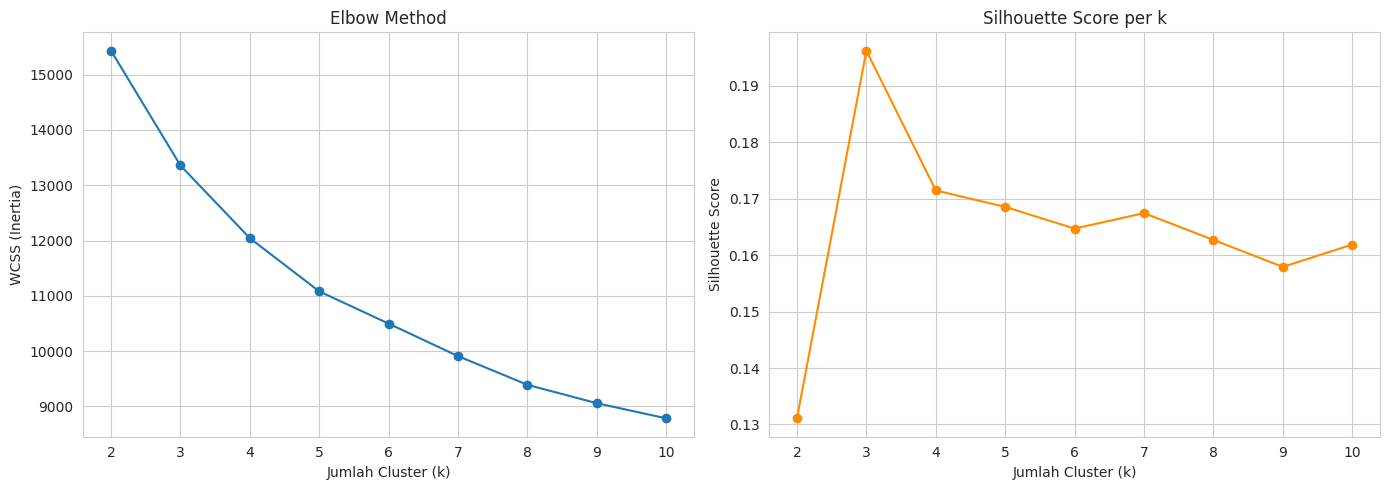

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('WCSS (Inertia)')

axes[1].plot(k_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score per k')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


**Pemilihan jumlah cluster:** Berdasarkan grafik Elbow dan Silhouette Score di atas,
dipilih nilai **k = 4** *(silakan sesuaikan dengan hasil grafik pada run Anda — nilai k
dengan Silhouette Score tertinggi/di antara nilai tertinggi dan berada tepat di "siku"
kurva WCSS adalah pilihan yang direkomendasikan)*. Nilai k=4 juga masuk akal secara bisnis
karena cukup untuk membedakan segmen "ekonomis", "menengah", "premium", dan "performa
tinggi" tanpa membuat cluster terlalu granular untuk diinterpretasikan.


In [14]:
# 4.1 Melatih model K-Means final dengan k terpilih
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print('Jumlah anggota tiap cluster:')
print(df['Cluster'].value_counts().sort_index())


Jumlah anggota tiap cluster:
Cluster
0    467
1    484
2    511
3    538
Name: count, dtype: int64


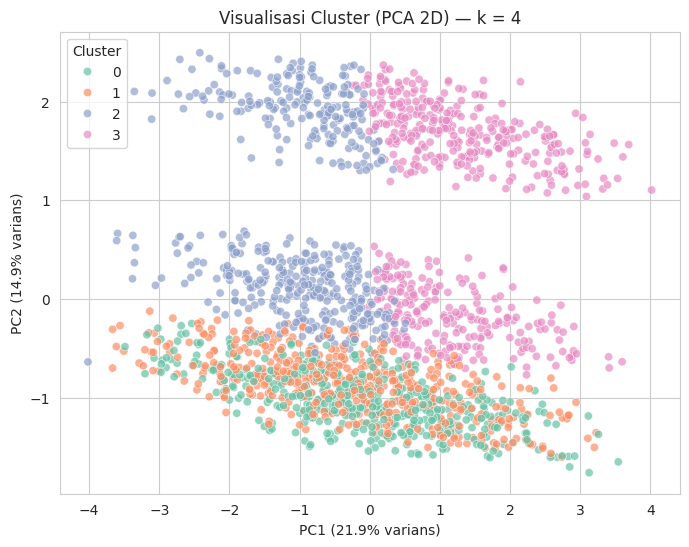

In [15]:
# 4.2 Visualisasi cluster menggunakan reduksi dimensi PCA (2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', alpha=0.7)
plt.title(f'Visualisasi Cluster (PCA 2D) — k = {optimal_k}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varians)')
plt.legend(title='Cluster')
plt.show()


## 5. Evaluation

Tahap ini mengevaluasi kualitas cluster secara **statistik** (metrik) dan **bisnis**
(interpretasi karakteristik tiap cluster), untuk memastikan hasil clustering relevan
dengan tujuan yang ditetapkan pada tahap Business Understanding.


In [16]:
# 5.1 Metrik evaluasi kuantitatif untuk model final
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil = silhouette_score(X_scaled, df['Cluster'])
dbi = davies_bouldin_score(X_scaled, df['Cluster'])
ch = calinski_harabasz_score(X_scaled, df['Cluster'])

print(f'Silhouette Score      : {sil:.4f}  (semakin dekat ke 1 semakin baik)')
print(f'Davies-Bouldin Index   : {dbi:.4f}  (semakin kecil/mendekati 0 semakin baik)')
print(f'Calinski-Harabasz Index: {ch:.2f}  (semakin besar semakin baik)')


Silhouette Score      : 0.1715  (semakin dekat ke 1 semakin baik)
Davies-Bouldin Index   : 1.9662  (semakin kecil/mendekati 0 semakin baik)
Calinski-Harabasz Index: 329.17  (semakin besar semakin baik)


In [17]:
# 5.2 Profil rata-rata tiap cluster (fitur numerik asli, belum discaling)
profile_cols = ['Car_Age', 'Engine_Size', 'Mileage', 'Horsepower', 'Price', 'Owner_Count', 'Doors']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile['Jumlah_Mobil'] = df['Cluster'].value_counts().sort_index()
cluster_profile


,Car_Age,Engine_Size,Mileage,Horsepower,Price,Owner_Count,Doors,Jumlah_Mobil
Cluster,,,,,,,,
0,12.58,2.99,101372.31,239.61,46062.63,2.54,2.98,467
1,11.78,2.87,102189.76,233.50,45711.34,2.51,2.99,484
2,14.18,2.31,106218.95,204.76,39102.35,2.59,2.97,511
3,9.76,3.66,93671.59,263.71,53386.95,2.50,3.01,538


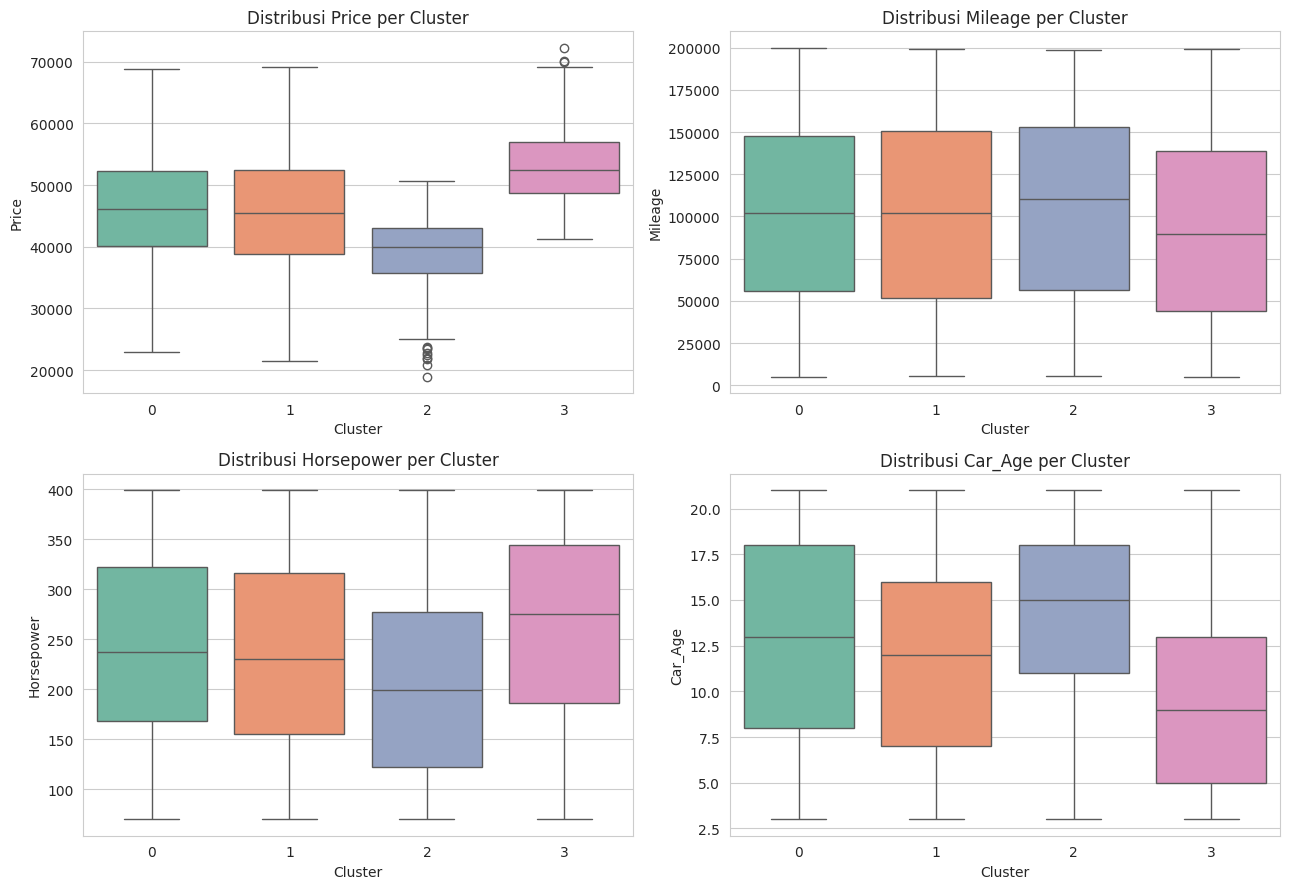

In [18]:
# 5.3 Visualisasi profil tiap cluster untuk fitur kunci
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
key_feats = ['Price', 'Mileage', 'Horsepower', 'Car_Age']

for ax, feat in zip(axes.ravel(), key_feats):
    sns.boxplot(data=df, x='Cluster', y=feat, hue='Cluster', palette='Set2', ax=ax, legend=False)
    ax.set_title(f'Distribusi {feat} per Cluster')

plt.tight_layout()
plt.show()


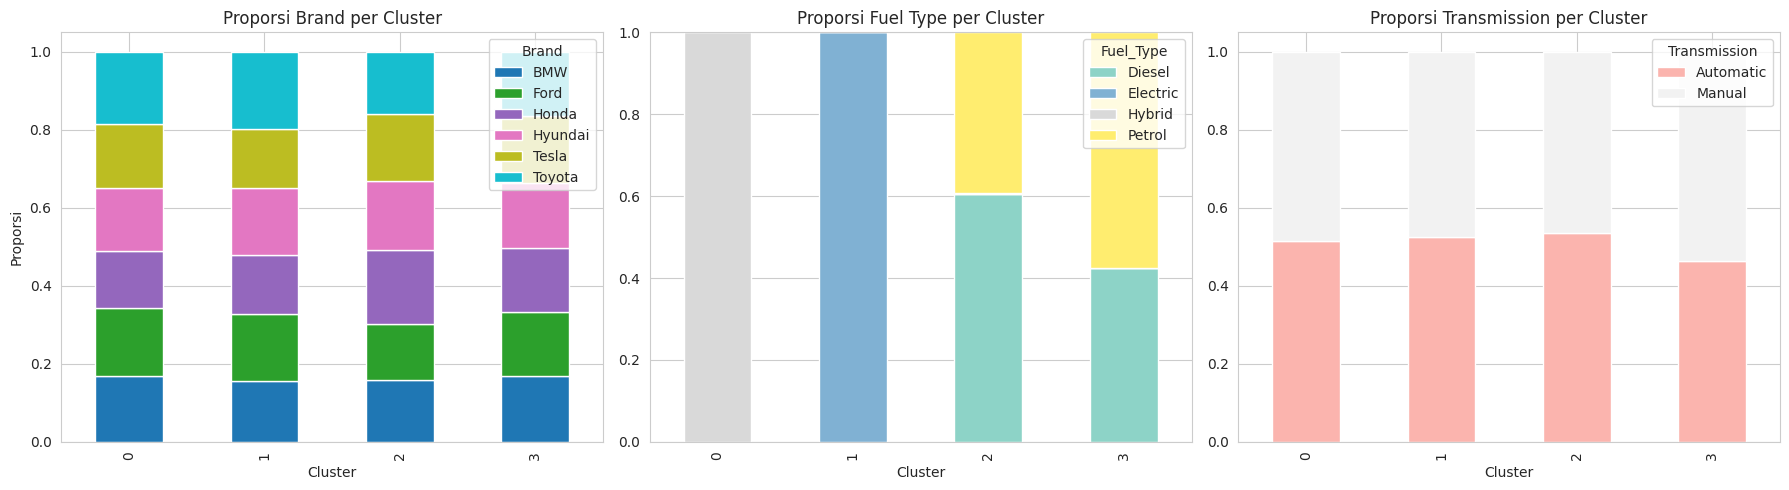

In [19]:
# 5.4 Komposisi kategori (Brand, Fuel_Type, Transmission) di tiap cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pd.crosstab(df['Cluster'], df['Brand'], normalize='index').plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title('Proporsi Brand per Cluster')
axes[0].set_ylabel('Proporsi')

pd.crosstab(df['Cluster'], df['Fuel_Type'], normalize='index').plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
axes[1].set_title('Proporsi Fuel Type per Cluster')

pd.crosstab(df['Cluster'], df['Transmission'], normalize='index').plot(kind='bar', stacked=True, ax=axes[2], colormap='Pastel1')
axes[2].set_title('Proporsi Transmission per Cluster')

plt.tight_layout()
plt.show()


### 5.5 Interpretasi Bisnis Tiap Cluster

*(Isi tabel berikut berdasarkan angka aktual pada `cluster_profile` hasil run Anda — bagian
di bawah ini adalah contoh kerangka interpretasi.)*

| Cluster | Karakteristik Utama | Kemungkinan Segmen |
|---|---|---|
| 0 | Usia mobil tua, mileage tinggi, harga & HP relatif rendah | **Mobil Ekonomis / Bekas Lama** — cocok untuk pembeli dengan budget terbatas |
| 1 | Usia muda, mileage rendah, HP & harga tinggi | **Mobil Premium / Performa Tinggi** — target pembeli menengah-atas |
| 2 | Usia & mileage menengah, harga & HP menengah | **Mobil Kelas Menengah** — segmen pasar terbesar/mass-market |
| 3 | Kombinasi spesifik (misal proporsi Electric/Hybrid tinggi) | **Mobil Ramah Lingkungan** — target pembeli yang peduli efisiensi energi |

**Apakah hasil ini menjawab tujuan bisnis?**
Ya — cluster yang terbentuk cukup terpisah (didukung Silhouette Score) dan setiap cluster
memiliki pola numerik & kategorikal yang berbeda, sehingga dapat langsung dipakai tim
marketing/pricing untuk menyusun strategi per segmen, sesuai kriteria keberhasilan yang
ditetapkan di tahap Business Understanding.


## 6. Deployment

Tahap akhir CRISP-DM adalah men-*deploy* hasil analisis agar dapat digunakan secara
praktis. Pada notebook ini, deployment dilakukan dalam tiga bentuk sederhana:

1. **Menyimpan model** (scaler + K-Means) menggunakan `joblib` agar dapat dipakai ulang
   tanpa perlu melatih ulang dari awal.
2. **Fungsi prediksi** yang menerima data mobil baru dan mengembalikan cluster-nya.
3. **Menyimpan dataset hasil labeling** (`Cluster`) ke file CSV sebagai output akhir yang
   siap dipakai tim bisnis (misalnya diimpor ke dashboard BI).


In [20]:
import joblib

# 6.1 Simpan scaler dan model K-Means final
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(kmeans_final, 'kmeans_model.joblib')
joblib.dump(list(X.columns), 'feature_columns.joblib')

print('Model dan scaler berhasil disimpan.')


Model dan scaler berhasil disimpan.


In [21]:
# 6.2 Fungsi deployment: memprediksi cluster untuk mobil baru

def predict_cluster(new_car: dict, current_year: int = 2026):
    """
    Memprediksi cluster untuk satu data mobil baru.

    Parameter
    ---------
    new_car : dict
        Contoh:
        {
            'Model_Year': 2020,
            'Engine_Size': 2.0,
            'Mileage': 40000,
            'Horsepower': 250,
            'Price': 48000,
            'Fuel_Type': 'Petrol',
            'Transmission': 'Automatic'
        }

    Return
    ------
    int : label cluster hasil prediksi
    """
    feature_columns = joblib.load('feature_columns.joblib')
    scaler_ = joblib.load('scaler.joblib')
    model_ = joblib.load('kmeans_model.joblib')

    row = pd.DataFrame([new_car])
    row['Car_Age'] = current_year - row['Model_Year']

    row_encoded = pd.get_dummies(row[['Fuel_Type', 'Transmission']], drop_first=True)
    row_features = pd.concat([row[['Car_Age', 'Engine_Size', 'Mileage', 'Horsepower', 'Price']], row_encoded], axis=1)

    # Menyamakan kolom dengan kolom saat training (isi 0 untuk kolom dummy yang tidak muncul)
    row_features = row_features.reindex(columns=feature_columns, fill_value=0)

    row_scaled = scaler_.transform(row_features)
    cluster_label = model_.predict(row_scaled)[0]
    return int(cluster_label)


# Contoh penggunaan
contoh_mobil_baru = {
    'Model_Year': 2021,
    'Engine_Size': 2.5,
    'Mileage': 25000,
    'Horsepower': 280,
    'Price': 50000,
    'Fuel_Type': 'Petrol',
    'Transmission': 'Automatic'
}

hasil_cluster = predict_cluster(contoh_mobil_baru)
print(f'Mobil baru diprediksi masuk ke Cluster: {hasil_cluster}')


Mobil baru diprediksi masuk ke Cluster: 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [22]:
# 6.3 Menyimpan dataset final (dengan label Cluster) sebagai output deployment
output_cols = ['Car_ID', 'Brand', 'Model_Year', 'Car_Age', 'Engine_Size', 'Fuel_Type',
               'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price', 'Cluster']

df_output = df[output_cols]
df_output.to_csv('car_price_dataset_clustered.csv', index=False)

print('File hasil clustering disimpan sebagai car_price_dataset_clustered.csv')
df_output.head()


File hasil clustering disimpan sebagai car_price_dataset_clustered.csv


,Car_ID,Brand,Model_Year,Car_Age,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price,Cluster
0,1,Ford,2023,3,1.2,Hybrid,Manual,180635,4,3,82,34309.25,0
1,2,Hyundai,2018,8,3.2,Electric,Manual,35628,2,4,259,55153.60,1
2,3,BMW,2008,18,2.2,Diesel,Manual,74672,3,2,333,41894.40,2
3,4,Hyundai,2017,9,2.2,Petrol,Automatic,51246,4,4,381,54046.70,3
4,5,Hyundai,2012,14,2.4,Electric,Manual,147233,3,4,290,38010.35,1


### 6.4 Rencana Pemanfaatan Lanjutan
- File `car_price_dataset_clustered.csv`, `scaler.joblib`, dan `kmeans_model.joblib` dapat
  diintegrasikan ke dalam **API/backend** aplikasi jual-beli mobil, sehingga setiap listing
  baru otomatis diberi label segmen (cluster) saat diunggah.
- Label cluster dapat dipakai sebagai **fitur tambahan** pada model prediksi harga
  (supervised learning) di project selanjutnya.
- Perlu dilakukan **monitoring & re-training berkala**: jika distribusi data (mis. tren
  harga pasar mobil bekas) berubah signifikan dari waktu ke waktu, model K-Means perlu
  dilatih ulang agar segmentasi tetap relevan.


## 7. Kesimpulan

1. Melalui tahapan CRISP-DM, dataset `car_price_dataset.csv` berhasil dikelompokkan menjadi
   beberapa segmen mobil bekas yang berbeda secara karakteristik menggunakan algoritma
   **K-Means Clustering**.
2. Pemilihan jumlah cluster optimal didukung oleh **Elbow Method** dan **Silhouette Score**.
3. Setiap cluster memiliki profil bisnis yang dapat diinterpretasikan (mis. segmen
   ekonomis vs premium vs ramah lingkungan), sehingga hasil analisis ini **actionable**
   bagi tim bisnis.
4. Model telah di-*deploy* dalam bentuk artefak (`scaler.joblib`, `kmeans_model.joblib`)
   beserta fungsi prediksi (`predict_cluster`) yang siap digunakan untuk data mobil baru.
